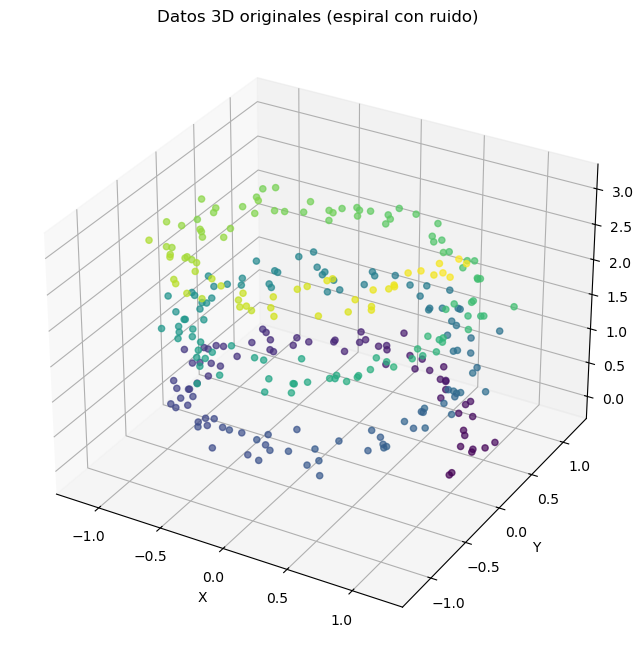

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

# Datos 3D sinteticos con ruido (para PCA)
N = 300
theta = np.linspace(0, 6*np.pi, N)
x = np.cos(theta) + np.random.normal(0, 0.1, N)
y = np.sin(theta) + np.random.normal(0, 0.1, N)
z = theta / (2*np.pi) + np.random.normal(0, 0.1, N)

X = np.column_stack((x, y, z))

# Grafico 3D original
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=theta, cmap='viridis', alpha=0.7)
ax.set_title('Datos 3D originales (espiral con ruido)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

In [3]:
def pca_from_scratch(X, n_components=2):
    """
    PCA manual: encuentra componentes principales.
    Tecnologia inversa: contrato → matriz de convarianza → eigenvalores/ vectores → proyeccion.
    """
    # 1. Contrato (restar media)
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean

    # 2. Matriz de covarianza
    cov_matrix = np.cov(X_centered.T) # (p x p)

    # 3. Eigenvalores y eigenvectores
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

    # Ordenar descendente
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # 4. Tomar n_components principales
    top_vectors = eigenvectors[:, :n_components]

    # 5. Proyeccion
    X_reduced = X_centered @ top_vectors

    return X_reduced, top_vectors, eigenvalues, X_mean

# Aplicar PCA
X_pca, components, eigenvalues, X_mean = pca_from_scratch(X, n_components=2)

print("Varianza explicada por componentes:")
print(eigenvalues / np.sum(eigenvalues) * 100)

Varianza explicada por componentes:
[47.84382182 28.75561562 23.40056256]


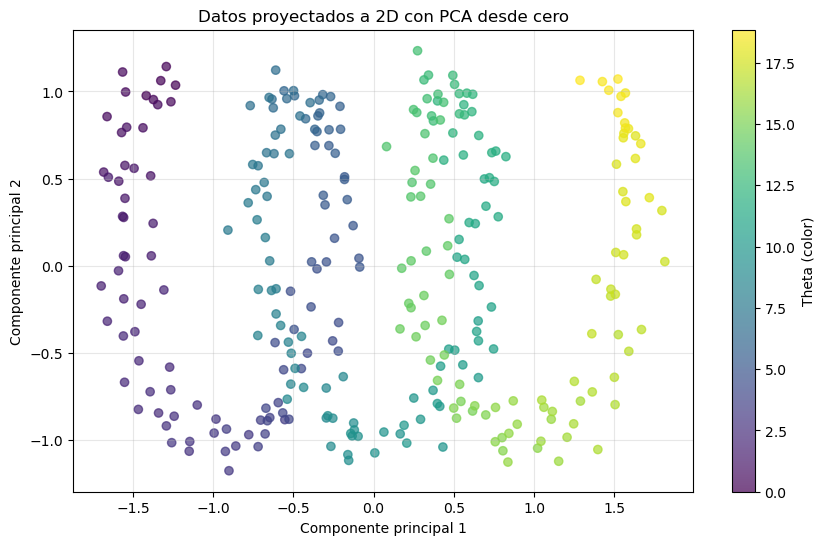

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=theta, cmap='viridis', alpha=0.7)
plt.colorbar(label='Theta (color)')
plt.title('Datos proyectados a 2D con PCA desde cero')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
def kmeans_from_scratch(X, k=3, max_iters=100, tol=1e-4):
    """
    K-means desde cero (Lloyd´s algorittm).
    Tecnologia inversa: inicializacion → asignacion → actualizacion → repetir hasta convergencia.
    """

    n_samples, n_features = X.shape

    # 1. Inicializacion: elegir k centroides al azar (metodo simple)
    centroid_idx = np.random.choice(n_samples, k, replace=False)
    centroids = X[centroid_idx]

    for iter in range(max_iters):
        # 2. Asignacion: cada punto al centroide mas cercano (distancia euclidiana)
        distances = np.linalg.norm(X[:, None] - centroids[None, :], axis=2) # (n_samples, k)
        labels = np.argmin(distances, axis=1) # indice del centroide mas cercano

        # 3. Actualizacion: nuevo centroide = medida de puntos asignados
        new_centroids = np.array([X[labels == i].mean(axis=0) if np.sum(labels == i) > 0 else centroids[i] for i in range(k)])

        # 4. Convergencia: si centroides no cambian mucho → parar
        shift = np.linalg.norm(new_centroids - centroids, axis=1).max()
        centroids = new_centroids

        if shift < tol:
            print(f"Convergencia en iteracion {iter+1}")
            break
    # Inercia (suma de distancias el cuadro al centroide)
    inertia = np.sum(np.min(distances, axis=1)**2)

    return labels, centroids, inertia

Convergencia en iteracion 8
Inercia (distorcion): 120.46


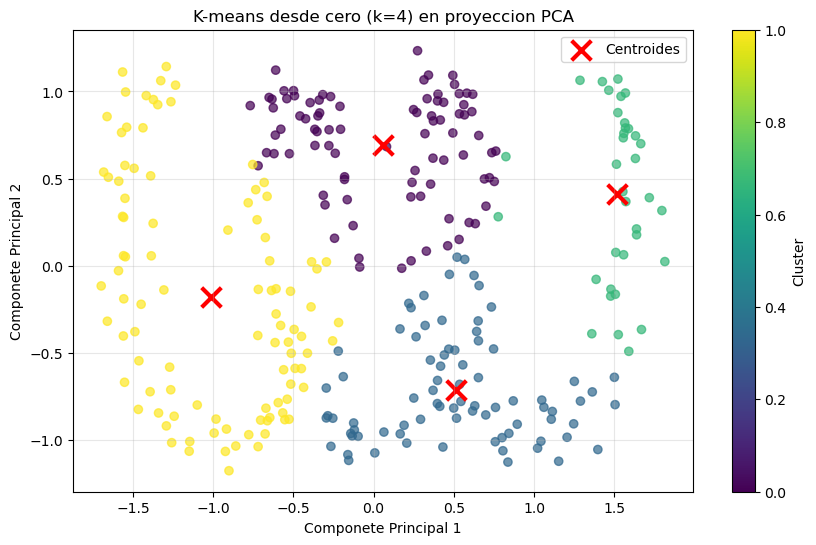

In [6]:
# Usamos los datos 2D de PCA (X_pca del paso anterior)
k = 4 # numero de clusters (Prueba 3, 4, 5 para ver)

labels, centroids, inertia = kmeans_from_scratch(X_pca, k=k)

print(f"Inercia (distorcion): {inertia:.2f}")

#Grafico clusters en 2D (PCA)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', alpha=0.7)
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='x', s=200, linewidths=3, label='Centroides')
plt.colorbar(label='Cluster')
plt.title(f'K-means desde cero (k={k}) en proyeccion PCA')
plt.xlabel('Componete Principal 1')
plt.ylabel('Componete Principal 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

def hierarchical_clustering_from_scratch(X, method='single', metric='euclidean'):
    """
    Clustering jerarquico desde cero (usando scipy para linkage y dendrograma).
    Tecnologia inversa: calcula matriz de distancia → linkage → dendrogram → clusters.
    """
    # 1. Matriz de distancia (condensada)
    distances = pdist(X, metric=metric)

    # 2. Linkage: une clusters mas cercanos segun metodo
    # - single: distancia minima entre puntos de clusters
    # - complete: distancia maxima
    # - average: distancia promedio
    Z = linkage(distances, method=method)

    return Z

# Usamos los datos 2D de PCA (X_pca del PCA anterior)
Z_single = hierarchical_clustering_from_scratch(X_pca, method='single')
Z_average =hierarchical_clustering_from_scratch(X_pca, method='average')
Z_ward = hierarchical_clustering_from_scratch(X_pca, method='ward')


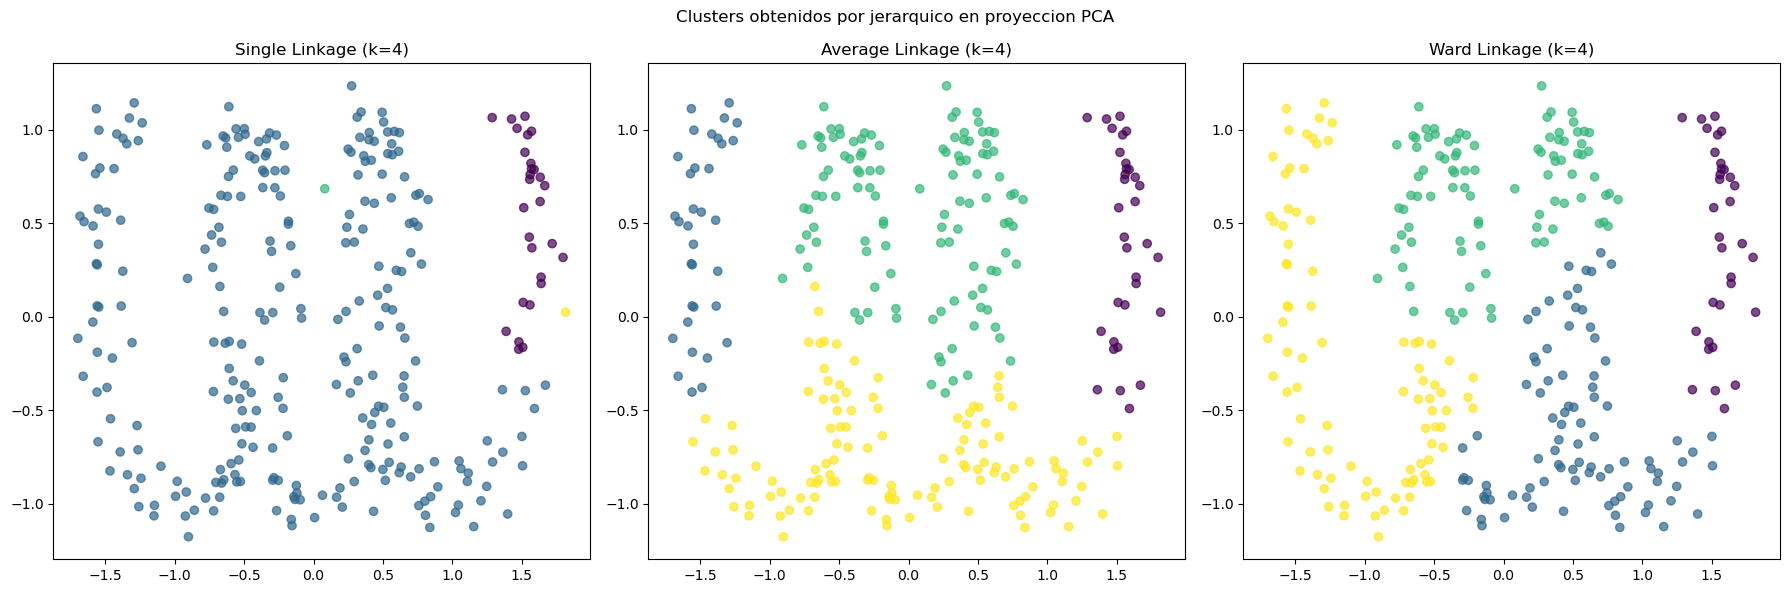

In [8]:
from scipy.cluster.hierarchy import fcluster

#Eligir numero de clusters (ej. corte a alturas 5 o k=4)
k = 4
labels_single = fcluster(Z_single, t=k, criterion='maxclust')
labels_average = fcluster(Z_average, t=k, criterion='maxclust')
labels_ward = fcluster(Z_ward, t=k, criterion='maxclust')

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].scatter(X_pca[:,0], X_pca[:,1], c=labels_single, cmap='viridis', alpha=0.7)
axs[0].set_title(f'Single Linkage (k={k})')

axs[1].scatter(X_pca[:,0], X_pca[:,1], c=labels_average, cmap='viridis', alpha=0.7)
axs[1].set_title(f'Average Linkage (k={k})')

axs[2].scatter(X_pca[:,0], X_pca[:,1], c=labels_ward, cmap='viridis', alpha=0.7)
axs[2].set_title(f'Ward Linkage (k={k})')

plt.suptitle('Clusters obtenidos por jerarquico en proyeccion PCA')
plt.tight_layout()
plt.show()


In [10]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

def hierarchical_clustering_from_scratch(X, method='single', metric='euclidean'):
    """
    Clustering jerarquico desde cero (usando scipy para linkage y dendrograma).
    Tecnologia inversa: calcula matriz de distancias → linkage → dendrograma → clusters.
    """ 
    # 1. Matriz de distancias (condensada)
    distances = pdist(X, metric=metric)

    # 2. Linkage: une clusters mas cercanos segun el metodo
    # - single: distancia minima entre puntos de clusters
    # - complete: distancia maxima
    # - average: distancia promedio
    Z = linkage(distances, method=method)

    return Z

# usamos los datos 2D de PCA (X_pca del PCA anterior)
Z_single = hierarchical_clustering_from_scratch(X_pca, method='single')
Z_average = hierarchical_clustering_from_scratch(X_pca, method='average')
Z_ward = hierarchical_clustering_from_scratch(X_pca, method='ward')

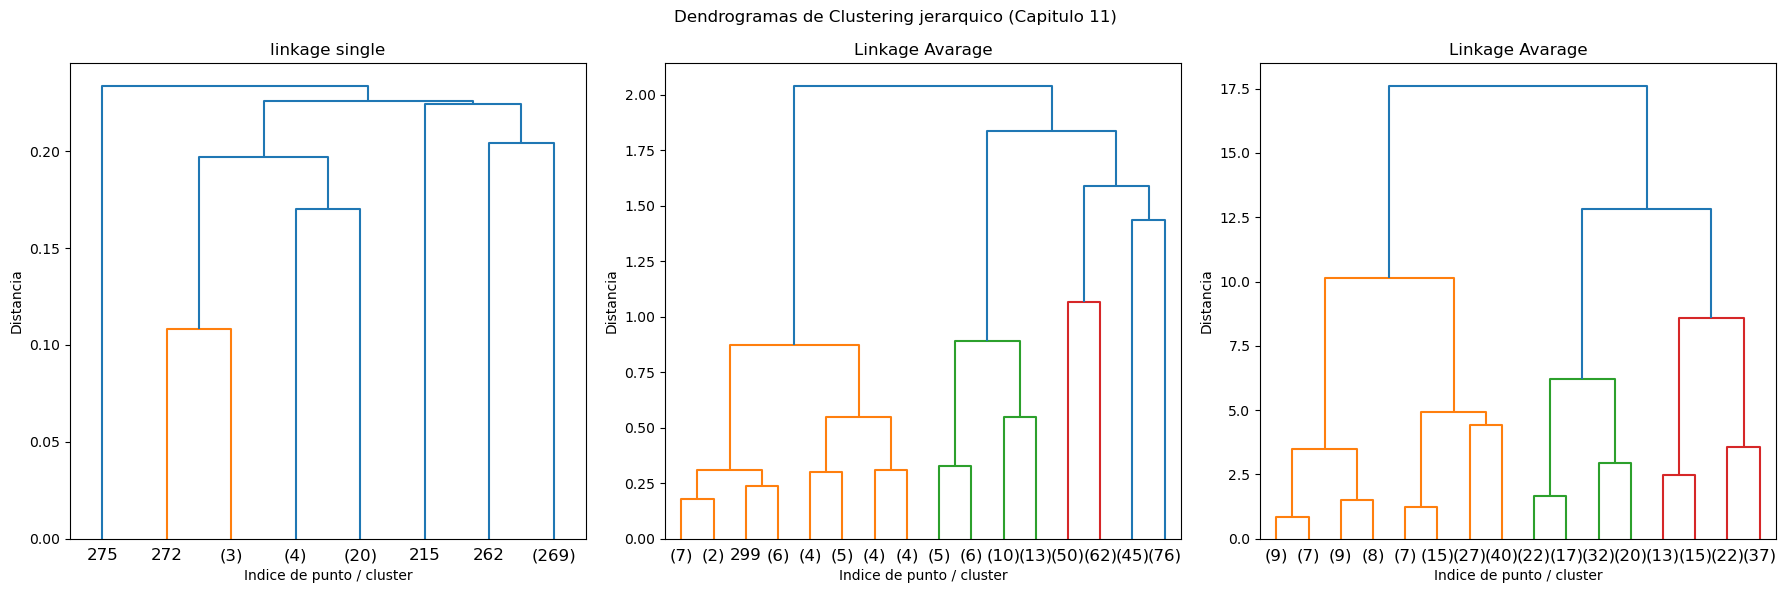

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

dendrogram(Z_single, ax=axs[0], truncate_mode='level', p=3)
axs[0].set_title('linkage single')
axs[0].set_xlabel('Indice de punto / cluster')
axs[0].set_ylabel('Distancia')

dendrogram(Z_average, ax=axs[1], truncate_mode='level', p=3)
axs[1].set_title('Linkage Avarage')
axs[1].set_xlabel('Indice de punto / cluster')
axs[1].set_ylabel('Distancia')

dendrogram(Z_ward, ax=axs[2], truncate_mode='level', p=3)
axs[2].set_title('Linkage Avarage')
axs[2].set_xlabel('Indice de punto / cluster')
axs[2].set_ylabel('Distancia')

plt.suptitle('Dendrogramas de Clustering jerarquico (Capitulo 11)')
plt.tight_layout()
plt.show()


In [ ]:
from scipy.cluster.hierarchy import fcluster

# Elegir numero de cluster (Ej. corte de altura 5 o k=4)
k = 4
labels_single = fcluster(Z_single, t=k, criterion='maxclust')
labels_average = fcluster(Z_average, t=k, criterion='maxclust')
labels_ward = fcluster(Z_ward, t=k, criterion='maxclust')

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].scatter(X_pca[:,0], X_pca[:,1], c=labels_single, cmap='viridis', alpha=0.7)
axs[0].set_title(f'Single linkage (k={k})')

axs[1].scatter(X_pca[:,0], X_pca[:,1], c=labels_average, cmap='viridis', alpha=0.7)
axs[1].set_title(f'Average linkage (k={k})')

axs[2].scatter(X_pca[:,0], X_pca[:,1], c=labels_ward, cmap='viridis', alpha=0.7)
axs[2].set_title(f'Ward linkage (k={k})')

plt.suptitle('Clusters obtenidos por jerarquico en proyeccion PCA')
plt.tight_layout()
plt.show()